# Helene GWR — Inflow & Outflow (Cluster-Level, N=38)

Companion to `helene_gwr.ipynb` (which covered the **within-region** flow). Same design, applied to the two remaining flow types so all three are documented.

**Definitions (recompute_flows.ipynb / CLAUDE.md §4.2):**
- **Inflow**: trips from origins *outside A* to destinations *inside cluster C*. Captures external support / arrivals.
- **Outflow**: trips from origins *inside C* to destinations *outside A*. Captures evacuation / exit dynamics. Reported as a **positive** deviation (largest_increase_outflow) — the maximum surge above baseline, not a drop.

**DVs (3):**
1. `largest_drop_inflow` — peak negative deviation in inflow during landing week
2. `recovery_days_inflow` — trend-based recovery time for inflow
3. `largest_increase_outflow` — peak positive deviation in outflow (evacuation surge). β-sign convention is **inverted** from drops: positive β = predictor associated with larger surge.

**IVs (same as within-GWR):** `median_household_income`, `pct_white`, `nchs_code`, `dist_to_track_mi`

**Note on CLAUDE.md §4.1:** That section says inflow is excluded at county/band level because a single county has no specific reason to receive external origins. At the **cluster** level (multi-county aggregation), inflow becomes more interpretable as aggregate external support, so we include it here with that justification.

**Same caveats as `helene_gwr.ipynb`:** N=38 is thin; bandwidth uncertainty is large; cluster centroids unweighted; Euclidean-centroid kernel (not track-distance); near-saturation features dropped. See its §8 limitations list.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

from libpysal.weights import Queen, KNN
from esda.moran import Moran
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

warnings.filterwarnings("ignore")

OUTPUT_DIR = "../results/helene_gwr_flow/"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Output dir: {OUTPUT_DIR}")
print("Setup complete.")

Output dir: ../results/helene_gwr_flow/
Setup complete.


/Users/qing/miniconda3/envs/geo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## §1. Load and prep

Same cluster GeoDataFrame as the within-GWR notebook.

In [2]:
# Cluster-level metrics from pooled dataset, filtered to Helene
pooled = pd.read_csv("../results/local_level/regression/pooled_dataset.csv")
helene = pooled[pooled["hurricane"] == "helene"].copy().reset_index(drop=True)
helene["cluster"] = helene["NAME"].str.replace("Cluster_", "").astype(int)

# County → cluster + geometries
ca = pd.read_csv("../results/helene_clustering/county_cluster_assignments.csv")
ca["GEOID"] = ca["GEOID"].astype(int)
county_shp = "./../../hurricane_oct/data/county_geo/tl_2023_us_county/tl_2023_us_county.shp"
counties_gdf = gpd.read_file(county_shp)
counties_gdf["GEOID"] = counties_gdf["GEOID"].astype(int)
gdf_counties = counties_gdf[counties_gdf["GEOID"].isin(ca["GEOID"])].copy()
gdf_counties = gdf_counties.merge(ca[["GEOID", "cluster"]], on="GEOID", how="left")
gdf_counties = gdf_counties.to_crs(epsg=5070)
gdf_clusters = gdf_counties.dissolve(by="cluster")[["geometry"]].reset_index()

gdf = gdf_clusters.merge(helene, on="cluster", how="left")
centroids = gdf.geometry.centroid
gdf["centroid_x"] = centroids.x
gdf["centroid_y"] = centroids.y

# Track for map overlay
from shapely.geometry import LineString
track_gdf = gpd.read_file("./../../hurricane_oct/data/storm_track/helene_storm_track.shp").to_crs(epsg=5070)
if track_gdf.geometry.geom_type.iloc[0] == "Point":
    track_line = LineString(track_gdf.geometry.tolist())
else:
    track_line = track_gdf.unary_union
track_line_gdf = gpd.GeoDataFrame(geometry=[track_line], crs="EPSG:5070")

# DV availability check
print(f"Helene clusters: N={len(gdf)}")
for col in ["largest_drop_inflow", "recovery_days_inflow", "largest_increase_outflow"]:
    n_valid = gdf[col].notna().sum()
    rng = (gdf[col].min(), gdf[col].max())
    print(f"  {col}: {n_valid}/{len(gdf)} valid, range=[{rng[0]:.2f}, {rng[1]:.2f}]")

Helene clusters: N=38
  largest_drop_inflow: 38/38 valid, range=[-42.15, 13.24]
  recovery_days_inflow: 31/38 valid, range=[1.04, 55.69]
  largest_increase_outflow: 38/38 valid, range=[-31.36, 105.69]


## §2. Global OLS baseline per DV

Three DVs, four standardized predictors. AICc anchor for GWR.

In [3]:
FEATURES = ["median_household_income", "pct_white", "nchs_code", "dist_to_track_mi"]
DVs = [
    ("largest_drop_inflow", "Largest Drop — Inflow (%)", "drop"),
    ("recovery_days_inflow", "Recovery Time — Inflow (days)", "drop"),
    ("largest_increase_outflow", "Outflow Increase (%)", "surge"),
]

def standardize(df, cols):
    sc = StandardScaler()
    Z = sc.fit_transform(df[cols])
    return pd.DataFrame(Z, columns=cols, index=df.index)

ols_results = {}
gdf_models = {}  # per-DV model subsets (NaN-dropped)

for dv_col, dv_label, kind in DVs:
    mask = gdf[FEATURES + [dv_col]].notna().all(axis=1)
    gm = gdf[mask].copy().reset_index(drop=True)
    if len(gm) < 10:
        print(f"\nSkipping {dv_label}: only {len(gm)} valid rows.")
        continue
    X_z = standardize(gm, FEATURES)
    X = sm.add_constant(X_z.values)
    y = gm[dv_col].values
    m = sm.OLS(y, X).fit()
    ols_results[dv_col] = m
    gm["_Xz"] = list(X_z.values)  # keep z-scored X with the gdf for downstream use
    gdf_models[dv_col] = (gm, X_z)
    print(f"\n{'='*70}")
    print(f"OLS: {dv_label}  (kind={kind}, N={len(gm)})")
    print(f"{'='*70}")
    print(f"R²={m.rsquared:.3f}  Adj.R²={m.rsquared_adj:.3f}  F p={m.f_pvalue:.4f}")
    print(f"  {'Variable':<28} {'β':>8} {'p':>8}")
    print("  " + "-"*46)
    for n, b, p in zip(["const"] + FEATURES, m.params, m.pvalues):
        sig = "**" if p < 0.05 else "*" if p < 0.10 else ""
        print(f"  {n:<28} {b:>8.3f} {p:>8.4f} {sig}")


OLS: Largest Drop — Inflow (%)  (kind=drop, N=38)
R²=0.123  Adj.R²=0.016  F p=0.3490
  Variable                            β        p
  ----------------------------------------------
  const                         -18.418   0.0000 **
  median_household_income        -3.653   0.1085 
  pct_white                      -2.055   0.3336 
  nchs_code                      -1.241   0.6003 
  dist_to_track_mi                0.095   0.9613 

OLS: Recovery Time — Inflow (days)  (kind=drop, N=31)
R²=0.251  Adj.R²=0.136  F p=0.0993
  Variable                            β        p
  ----------------------------------------------
  const                          10.989   0.0000 **
  median_household_income        -2.807   0.1854 
  pct_white                       5.142   0.0145 **
  nchs_code                      -1.763   0.4284 
  dist_to_track_mi               -2.128   0.2498 

OLS: Outflow Increase (%)  (kind=surge, N=38)
R²=0.250  Adj.R²=0.159  F p=0.0446
  Variable                            β 

## §3. Spatial diagnostics — "should we GWR" gate per DV

In [4]:
diag_rows = []
PROCEED = {}

for dv_col, dv_label, kind in DVs:
    if dv_col not in gdf_models:
        continue
    gm, _ = gdf_models[dv_col]
    w_queen = Queen.from_dataframe(gm)
    w_knn = KNN.from_dataframe(gm, k=4)
    resid = ols_results[dv_col].resid
    print(f"\n--- {dv_label} ---")
    flags = []
    for w_, wlabel in [(w_queen, "Queen"), (w_knn, "KNN4")]:
        try:
            mi = Moran(resid, w_, permutations=999)
            print(f"  Moran's I ({wlabel}): I={mi.I:+.3f}, p_sim={mi.p_sim:.3f}")
            diag_rows.append({"dv": dv_label, "test": f"Moran_{wlabel}",
                              "stat": round(mi.I, 4), "p": round(mi.p_sim, 4)})
            flags.append(mi.p_sim < 0.10)
        except Exception as e:
            print(f"  Moran's I ({wlabel}) failed: {e}")
    rho_x, p_x = spearmanr(gm["centroid_x"], resid)
    rho_y, p_y = spearmanr(gm["centroid_y"], resid)
    print(f"  Spearman resid vs centroid_x: ρ={rho_x:+.3f}, p={p_x:.3f}")
    print(f"  Spearman resid vs centroid_y: ρ={rho_y:+.3f}, p={p_y:.3f}")
    diag_rows.append({"dv": dv_label, "test": "Spearman_resid_x",
                      "stat": round(rho_x, 4), "p": round(p_x, 4)})
    diag_rows.append({"dv": dv_label, "test": "Spearman_resid_y",
                      "stat": round(rho_y, 4), "p": round(p_y, 4)})
    flags.extend([p_x < 0.10, p_y < 0.10])
    PROCEED[dv_col] = bool(any(flags))
    print(f"  → PROCEED_GWR[{dv_col}] = {PROCEED[dv_col]}")

diag_df = pd.DataFrame(diag_rows)
diag_df.to_csv(os.path.join(OUTPUT_DIR, "spatial_diagnostics.csv"), index=False)
print("\nSaved spatial_diagnostics.csv")
print("\nProceed flags:", PROCEED)


--- Largest Drop — Inflow (%) ---
  Moran's I (Queen): I=+0.001, p_sim=0.385
  Moran's I (KNN4): I=-0.188, p_sim=0.046
  Spearman resid vs centroid_x: ρ=-0.011, p=0.947
  Spearman resid vs centroid_y: ρ=+0.038, p=0.823
  → PROCEED_GWR[largest_drop_inflow] = True

--- Recovery Time — Inflow (days) ---
  Moran's I (Queen): I=+0.049, p_sim=0.187
  Moran's I (KNN4): I=+0.059, p_sim=0.160
  Spearman resid vs centroid_x: ρ=-0.095, p=0.612
  Spearman resid vs centroid_y: ρ=+0.197, p=0.288
  → PROCEED_GWR[recovery_days_inflow] = False

--- Outflow Increase (%) ---
  Moran's I (Queen): I=+0.144, p_sim=0.049
  Moran's I (KNN4): I=-0.061, p_sim=0.386
  Spearman resid vs centroid_x: ρ=+0.134, p=0.422
  Spearman resid vs centroid_y: ρ=-0.231, p=0.162
  → PROCEED_GWR[largest_increase_outflow] = True

Saved spatial_diagnostics.csv

Proceed flags: {'largest_drop_inflow': True, 'recovery_days_inflow': False, 'largest_increase_outflow': True}


## §4. GWR fit (per DV that passed §3)

In [5]:
gwr_results = {}

for dv_col, dv_label, kind in DVs:
    if dv_col not in gdf_models:
        continue
    if not PROCEED.get(dv_col, False):
        print(f"\n[{dv_label}] PROCEED=False — skipping GWR fit.")
        continue
    gm, X_z = gdf_models[dv_col]
    coords = list(zip(gm["centroid_x"].values, gm["centroid_y"].values))
    X_mat = X_z.values
    y = gm[[dv_col]].values
    n_vars_eff = X_mat.shape[1] + 1
    bw_min_adapt = max(n_vars_eff + 3, 8)
    bw_max_adapt = len(gm) - 1
    print(f"\n{'='*70}")
    print(f"GWR: {dv_label}  (N={len(gm)}, bw bounds [{bw_min_adapt}, {bw_max_adapt}])")
    print(f"{'='*70}")
    sel = Sel_BW(coords, y, X_mat, fixed=False, kernel="bisquare")
    try:
        bw = sel.search(criterion="AICc", bw_min=bw_min_adapt, bw_max=bw_max_adapt)
        print(f"  Optimal adaptive bandwidth (k neighbors): {bw}")
        gwr_mod = GWR(coords, y, X_mat, bw, fixed=False, kernel="bisquare").fit()
        print(f"  AICc: {gwr_mod.aicc:.2f}  R²: {gwr_mod.R2:.3f}  Adj.R²: {gwr_mod.adj_R2:.3f}")
        print(f"  Effective n. parameters: {gwr_mod.ENP:.1f}")
        print(f"  Local R² range: [{gwr_mod.localR2.min():.3f}, {gwr_mod.localR2.max():.3f}]")
        gwr_results[dv_col] = {"model": gwr_mod, "bw": bw, "selector": sel, "gm": gm}
    except Exception as e:
        print(f"  GWR failed: {e}")
        gwr_results[dv_col] = None


GWR: Largest Drop — Inflow (%)  (N=38, bw bounds [8, 37])
  Optimal adaptive bandwidth (k neighbors): 33.0
  AICc: 302.63  R²: 0.399  Adj.R²: 0.209
  Effective n. parameters: 8.9
  Local R² range: [0.295, 0.396]

[Recovery Time — Inflow (days)] PROCEED=False — skipping GWR fit.

GWR: Outflow Increase (%)  (N=38, bw bounds [8, 37])
  Optimal adaptive bandwidth (k neighbors): 36.0
  AICc: 365.47  R²: 0.379  Adj.R²: 0.208
  Effective n. parameters: 8.0
  Local R² range: [0.249, 0.561]


## §5. Diagnostics — AICc + Monte Carlo non-stationarity

In [6]:
def ols_aicc(m, n):
    k = m.df_model + 1
    return m.aic + (2 * k * (k + 1)) / max(n - k - 1, 1)

comp_rows = []
nsta_rows = []
for dv_col, dv_label, kind in DVs:
    if dv_col not in ols_results:
        continue
    gm, _ = gdf_models[dv_col]
    ols_m = ols_results[dv_col]
    row = {"dv": dv_label, "kind": kind, "N": len(gm),
           "OLS_AICc": round(ols_aicc(ols_m, len(gm)), 2),
           "OLS_R2": round(ols_m.rsquared, 3),
           "OLS_adjR2": round(ols_m.rsquared_adj, 3)}
    if gwr_results.get(dv_col):
        g = gwr_results[dv_col]
        gm_mod = g["model"]
        row.update({"GWR_AICc": round(gm_mod.aicc, 2),
                    "GWR_R2": round(gm_mod.R2, 3),
                    "GWR_adjR2": round(gm_mod.adj_R2, 3),
                    "GWR_bw": g["bw"]})
        # Non-stationarity test
        print(f"\nNon-stationarity test: {dv_label}")
        try:
            pvals = gm_mod.spatial_variability(g["selector"], n_iters=200)
            for nm, pv in zip(["intercept"] + FEATURES, pvals):
                sig = "**" if pv < 0.05 else "*" if pv < 0.10 else ""
                print(f"  {nm:<28} p={float(pv):.3f} {sig}")
                nsta_rows.append({"dv": dv_label, "variable": nm,
                                  "p_nonstationarity": round(float(pv), 4)})
        except Exception as e:
            print(f"  spatial_variability failed: {e}")
    comp_rows.append(row)

comp_df = pd.DataFrame(comp_rows)
comp_df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison_aicc.csv"), index=False)
if nsta_rows:
    pd.DataFrame(nsta_rows).to_csv(os.path.join(OUTPUT_DIR, "nonstationarity_test.csv"), index=False)
print("\nModel comparison (lower AICc is better):")
print(comp_df.to_string(index=False))


Non-stationarity test: Largest Drop — Inflow (%)


Testing: 100%|██████████| 200/200 [00:20<00:00,  9.96it/s]


  intercept                    p=0.245 
  median_household_income      p=0.475 
  pct_white                    p=0.160 
  nchs_code                    p=0.355 
  dist_to_track_mi             p=0.000 **

Non-stationarity test: Outflow Increase (%)


Testing: 100%|██████████| 200/200 [00:19<00:00, 10.07it/s]

  intercept                    p=0.105 
  median_household_income      p=0.540 
  pct_white                    p=0.095 *
  nchs_code                    p=0.050 *
  dist_to_track_mi             p=0.520 

Model comparison (lower AICc is better):
                           dv  kind  N  OLS_AICc  OLS_R2  OLS_adjR2  GWR_AICc  GWR_R2  GWR_adjR2  GWR_bw
    Largest Drop — Inflow (%)  drop 38    301.16   0.123      0.016    302.63   0.399      0.209    33.0
Recovery Time — Inflow (days)  drop 31    237.22   0.251      0.136       NaN     NaN        NaN     NaN
         Outflow Increase (%) surge 38    360.13   0.250      0.159    365.47   0.379      0.208    36.0


## §6. Maps — β and t-stat per DV that fit

Sign-convention reminders:
- `largest_drop_inflow` is **negative** (a drop). β negative on a predictor → larger drop (more negative).
- `recovery_days_inflow` is **positive** (days). β positive → slower recovery.
- `largest_increase_outflow` is **positive** (a surge). β positive → larger evacuation surge.

**To compare with `helene_gwr.ipynb` (within-flow) maps, use the same colour-direction convention: red = positive coefficient, blue = negative.**

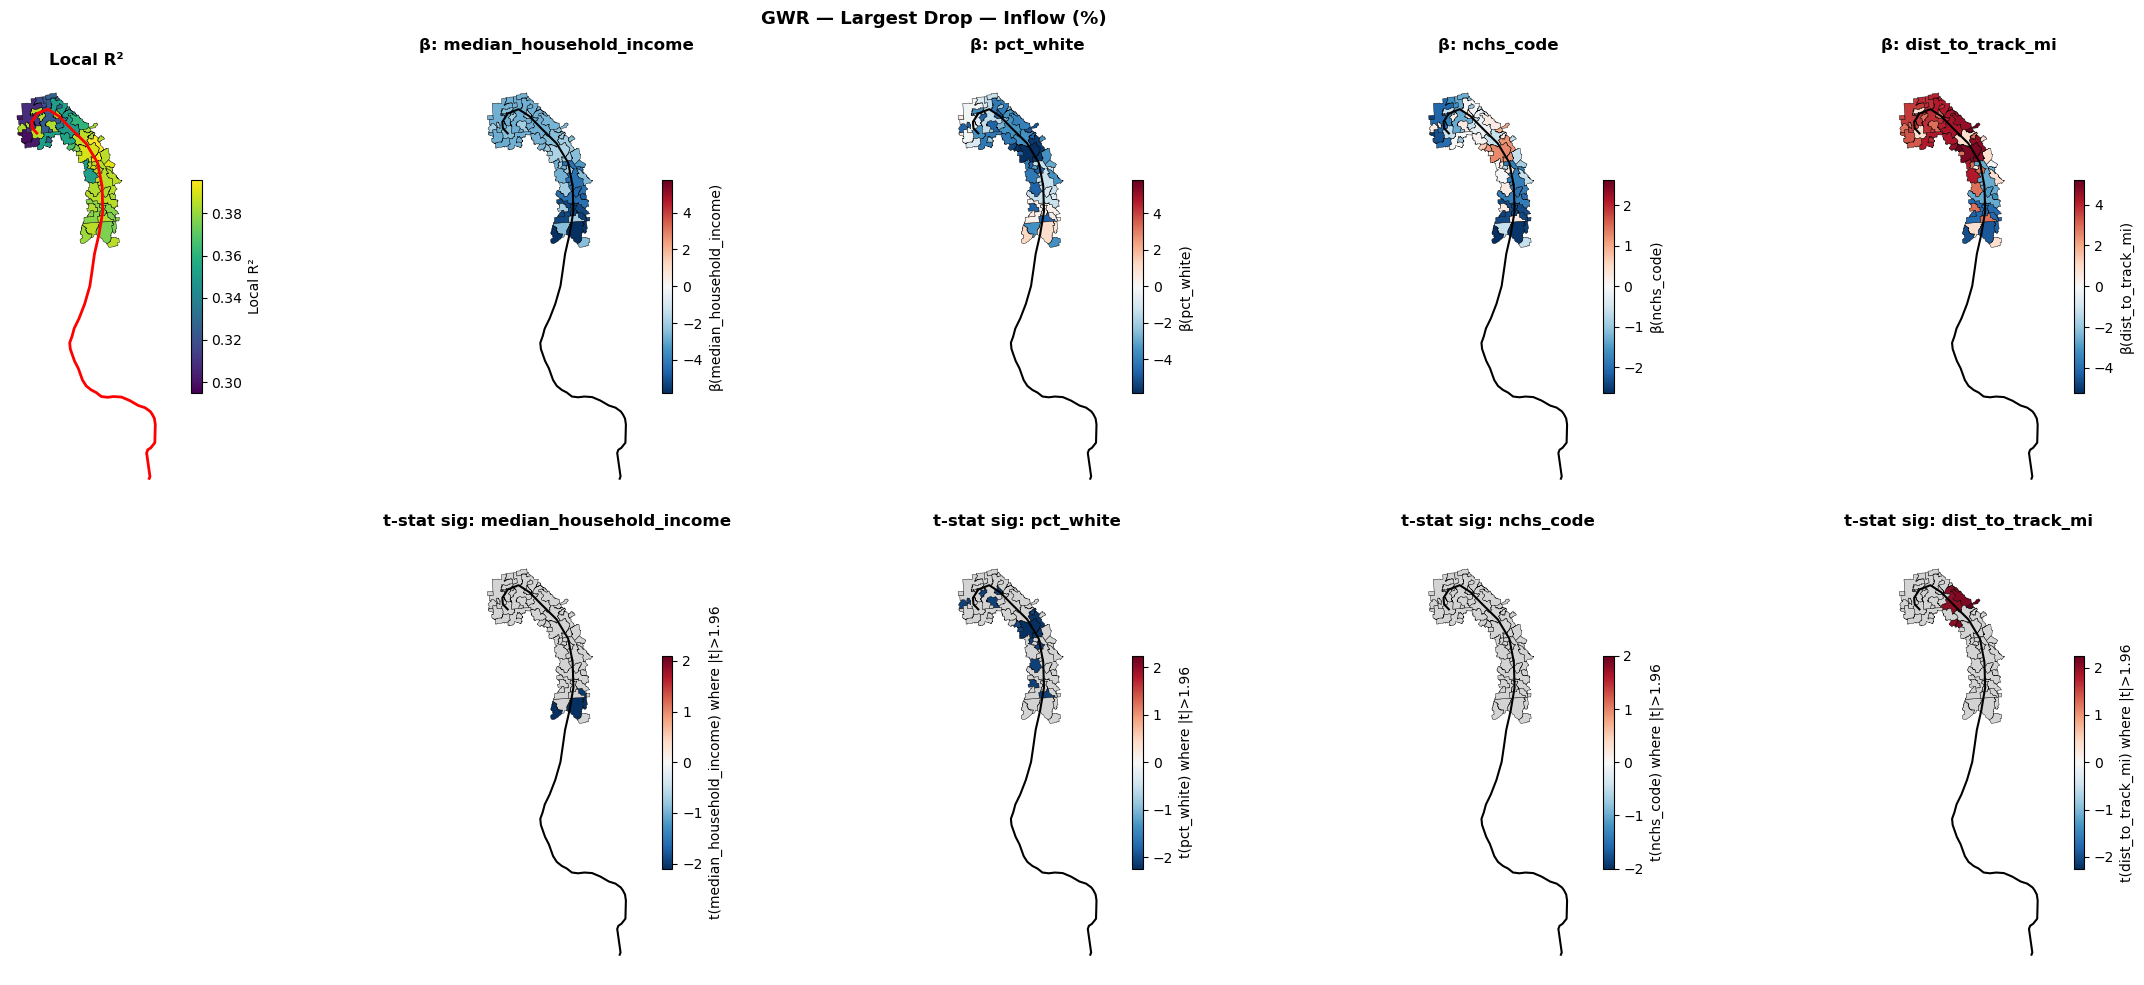

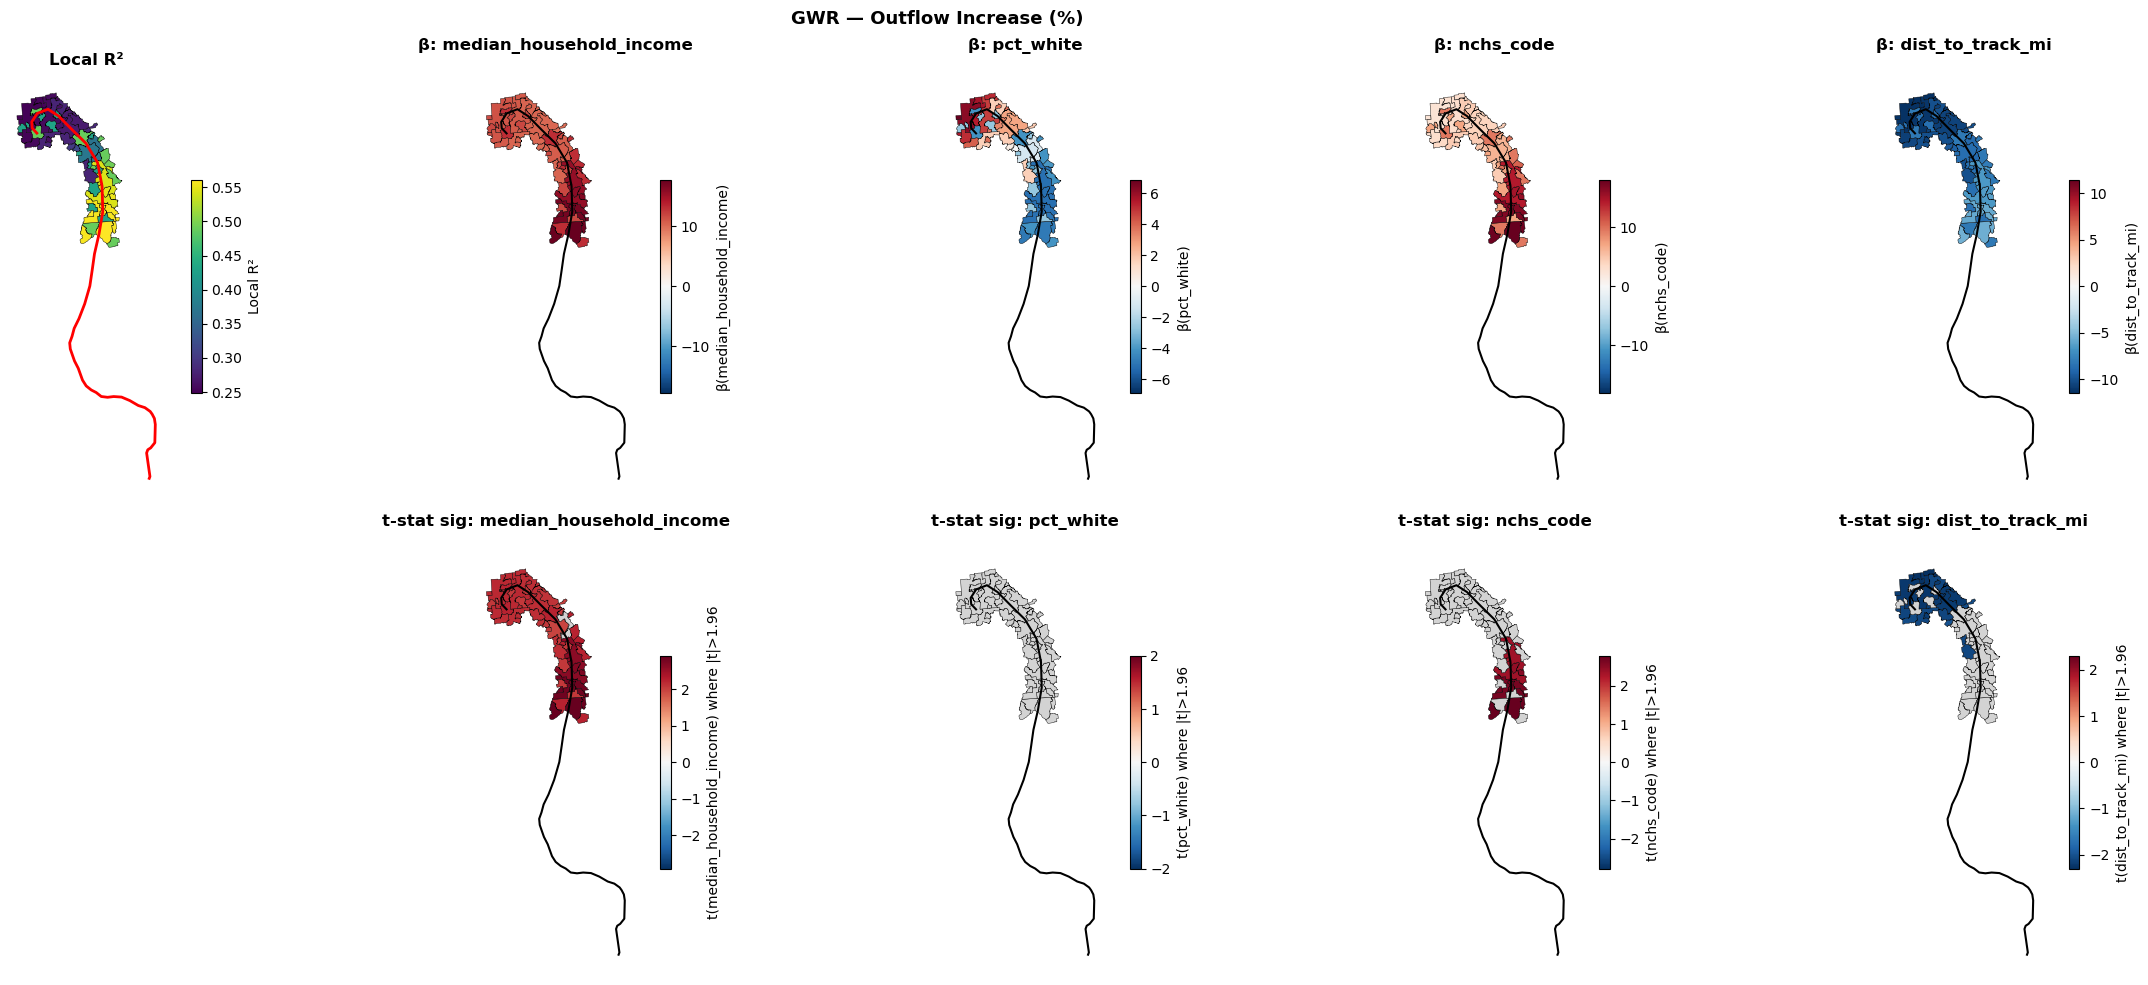

In [7]:
def plot_gwr_panel(gm_in, gwr_mod, dv_label, dv_key, feat_names, fig_dir, track_gdf):
    gp = gm_in.copy()
    gp["local_R2"] = gwr_mod.localR2.flatten()
    for i, fn in enumerate(["intercept"] + feat_names):
        gp[f"beta_{fn}"] = gwr_mod.params[:, i]
        gp[f"tval_{fn}"] = gwr_mod.tvalues[:, i]
    n_pred = len(feat_names)
    fig, axes = plt.subplots(2, n_pred + 1, figsize=(5 * (n_pred + 1), 10))
    # Local R²
    ax = axes[0, 0]
    gp.plot(column="local_R2", cmap="viridis", legend=True,
            edgecolor="black", linewidth=0.3, ax=ax,
            legend_kwds={"label": "Local R²", "shrink": 0.5})
    track_gdf.plot(ax=ax, color="red", linewidth=2)
    ax.set_title("Local R²", fontweight="bold"); ax.set_axis_off()
    axes[1, 0].set_visible(False)
    for j, fn in enumerate(feat_names):
        ax = axes[0, j + 1]
        v = np.abs(gp[f"beta_{fn}"]).max()
        gp.plot(column=f"beta_{fn}", cmap="RdBu_r", vmin=-v, vmax=v, legend=True,
                edgecolor="black", linewidth=0.3, ax=ax,
                legend_kwds={"label": f"β({fn})", "shrink": 0.5})
        track_gdf.plot(ax=ax, color="black", linewidth=1.5)
        ax.set_title(f"β: {fn}", fontweight="bold"); ax.set_axis_off()
        ax = axes[1, j + 1]
        gp["_sig"] = np.where(np.abs(gp[f"tval_{fn}"]) > 1.96, gp[f"tval_{fn}"], np.nan)
        v2 = max(np.nanmax(np.abs(gp["_sig"])) if gp["_sig"].notna().any() else 0, 2)
        gp.plot(column="_sig", cmap="RdBu_r", vmin=-v2, vmax=v2,
                missing_kwds={"color": "lightgrey"}, legend=True,
                edgecolor="black", linewidth=0.3, ax=ax,
                legend_kwds={"label": f"t({fn}) where |t|>1.96", "shrink": 0.5})
        track_gdf.plot(ax=ax, color="black", linewidth=1.5)
        ax.set_title(f"t-stat sig: {fn}", fontweight="bold"); ax.set_axis_off()
    fig.suptitle(f"GWR — {dv_label}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, f"gwr_{dv_key}.png"), dpi=150, bbox_inches="tight")
    plt.show()
    return gp

for dv_col, dv_label, kind in DVs:
    if gwr_results.get(dv_col):
        g = gwr_results[dv_col]
        plot_gwr_panel(g["gm"], g["model"], dv_label, dv_col, FEATURES, FIG_DIR, track_line_gdf)

## §7. Local coefficient exports

In [8]:
for dv_col, dv_label, kind in DVs:
    if not gwr_results.get(dv_col):
        continue
    g = gwr_results[dv_col]
    gm_mod = g["model"]
    gm_in = g["gm"]
    df_out = gm_in[["cluster", "centroid_x", "centroid_y", "nchs_code"]].copy()
    df_out["local_R2"] = gm_mod.localR2.flatten()
    for i, fn in enumerate(["intercept"] + FEATURES):
        df_out[f"beta_{fn}"] = gm_mod.params[:, i]
        df_out[f"tval_{fn}"] = gm_mod.tvalues[:, i]
    fn_out = os.path.join(OUTPUT_DIR, f"gwr_local_coefficients_{dv_col}.csv")
    df_out.to_csv(fn_out, index=False)
    print(f"Saved: {fn_out}")

print("\nAll outputs in:", OUTPUT_DIR)
for fn in sorted(os.listdir(OUTPUT_DIR)):
    p = os.path.join(OUTPUT_DIR, fn)
    if os.path.isfile(p):
        print(f"  {fn} ({os.path.getsize(p):,} bytes)")

Saved: ../results/helene_gwr_flow/gwr_local_coefficients_largest_drop_inflow.csv
Saved: ../results/helene_gwr_flow/gwr_local_coefficients_largest_increase_outflow.csv

All outputs in: ../results/helene_gwr_flow/
  gwr_local_coefficients_largest_drop_inflow.csv (10,035 bytes)
  gwr_local_coefficients_largest_increase_outflow.csv (9,787 bytes)
  model_comparison_aicc.csv (283 bytes)
  nonstationarity_test.csv (471 bytes)
  spatial_diagnostics.csv (674 bytes)


## §8. Summary template (fill in once §4 results print)

After the cells above run, capture:

1. **Inflow drop** — does the global income / pct_white / distance effect vary spatially? Compare local β maps to the within-drop maps in `helene_gwr.ipynb`. If the *coastal-vs-inland* localization pattern repeats for inflow, it strengthens the two-regime claim. If it doesn't, inflow disruption is its own story.
2. **Inflow recovery** — the regional-level finding (Helene §6 in `regional_metrics.ipynb`) was that inflow takes ~11 days vs. ~5 days for within. At cluster level, does this longer recovery have spatially varying SES drivers?
3. **Outflow increase** — Helene's outflow surge was *modest* compared to Milton's. Cluster-level GWR may show that the surge is concentrated in specific places (e.g., near track) without strong SES predictors. If `is_coastal`-like geographic effects swamp SES effects here, that's consistent with the pooled OLS finding (coastal +39% in Milton+Helene combined).

**Caveats inherited from `helene_gwr.ipynb`:** N=38 thin; bandwidth likely near-global; NCHS-homogeneous clustering pre-absorbs spatial heterogeneity; Euclidean kernel (not hydrologic); MGWR not attempted here because it failed in the within-flow notebook with the same N constraint.

Once outputs are reviewed, update [findings.md](../notes/findings.md) §"Sensitivity to Okeechobee — Pooled Model" with a new subsection summarizing inflow/outflow GWR.